In [1]:
import os

import pandas as pd

In [ ]:
!wget -P /home/dcm/bioinformatic_scripts/blast_databases/ https://card.mcmaster.ca/download/0/broadstreet-v4.0.1.tar.bz2


In [ ]:
!mkdir  /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1

In [ ]:
!tar -xvjf /home/dcm/bioinformatic_scripts/blast_databases/broadstreet-v4.0.1.tar.bz2 -C /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/

In [ ]:
!rm /home/dcm/bioinformatic_scripts/blast_databases/broadstreet-v4.0.1.tar.bz2

In [ ]:
!ls /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/*fasta

In [ ]:
!cat /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/protein_fasta*.fasta > /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/CARD_protein.fasta

In [ ]:
!/home/dcm/diamond makedb --in /home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/CARD_protein.fasta -d /home/dcm/bioinformatic_scripts/blast_databases/CARD_protein

In [ ]:
os.makedirs('CARD_diamond', exist_ok=True)

final_df = pd.DataFrame()

project_list = [
    '/home/dcm/250513Pat',
    '/home/dcm/250728Pat',
    '/home/dcm/250930Pat'
    ]

for project in project_list:

    file_df = pd.read_csv(f'{project}/files.txt', sep='\t')
    
    for folder, file in zip(file_df['folder'], file_df['file']):

        os.system(f'/home/dcm/diamond blastp \
        -d /home/dcm/bioinformatic_scripts/blast_databases/CARD_protein.dmnd \
        -q {project}/annotation_output/protein_annotations/annotations_{file}_scaffolds_1000bp.feature_protein.fasta \
        -o CARD_diamond/{file}_CARD_out.txt \
        -f 6 qseqid qlen sseqid slen qseq sseq evalue bitscore pident qcovhsp salltitles \
        -k 1')

In [ ]:
!cat CARD_diamond/*CARD_out.txt > CARD_diamond/CARD_cat.txt

In [2]:
headers = [
    "qseqid",
    "qlen",
    "sseqid",
    "slen",
    "qseq",
    "sseq",
    "evalue",
    "bitscore",
    "pident",
    "qcovhsp",
    "salltitles",
]

df_card = pd.read_csv('CARD_diamond/CARD_cat.txt', sep = '\t', names = headers)
df_card["ARO Accession"] = df_card["sseqid"].str.extract(r"(ARO:\d+)")
df_card_meta = pd.read_csv('/home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/aro_index.tsv', sep = '\t')
dfm = pd.merge(df_card, df_card_meta, how = 'left', on = "ARO Accession")
dfm

,qseqid,qlen,sseqid,slen,qseq,sseq,evalue,bitscore,pident,qcovhsp,...,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,fig|2.65351.peg.6,457,gb|ADO96486.1|ARO:3003953|hmrM,464,MQKYFIEARQLLALAIPVILAQVAQTSMGFVDTVMAGGYSATDMAA...,LSQYHTDIKKLIKISLPILLAQIAQNSMGLADTIMAGRVSSTDMAA...,4.180000e-139,405.0,45.9,99.3,...,5260,2425,hmrM,hmrM,ADO96486.1,CP002276.1,multidrug and toxic compound extrusion (MATE) ...,disinfecting agents and antiseptics;fluoroquin...,antibiotic efflux,hmrM
1,fig|2.65351.peg.10,394,gb|ALV80601.1|ARO:3003801|bcr-1,402,QPGKGFLVWLAGLSVLGFLATDMYLPAFSAIQQDLNTSAASVSASL...,QVGSGERRLLLLLSALVAFGPLSIDMYLPSLPAIAADLGASDAQVQ...,1.090000e-40,146.0,33.6,79.7,...,4627,2303,bcr-1,bcr-1,ALV80601.1,CP012901.1,major facilitator superfamily (MFS) antibiotic...,bicyclomycin-like antibiotic,antibiotic efflux,bcr-1
2,fig|2.65351.peg.14,388,gb|AAB36568.1|ARO:3002700|cmlv,436,LAIGAFGIGTTEFSPMGLLPVIAKGVDVSIPAAGMLISAYAIGVMV...,LGLSAFALGTSEFMLSGLVPPIAEDMNVSIPRAGLLISAFAIGMVV...,2.080000e-62,204.0,35.5,97.2,...,82,703,cmlv,cmlv,AAB36568.1,U09991.1,chloramphenicol phosphotransferase,phenicol antibiotic,antibiotic inactivation,cmlv
3,fig|2.65351.peg.19,135,gb|BAJ10053.1|ARO:3002874|FosC2,132,HTMLRVGDLQRSIEFYTNVLGMKLLRTSENTEYKYSLAFVGYGEES...,HITIAVSDLERSVEFYTRLLGMKAHVRWDSGAYLSLEATWICLSCD...,5.170000e-06,40.8,28.2,88.1,...,580,2060,FosC2,FosC2,BAJ10053.1,AB522969.1,fosC phosphotransferase family,phosphonic acid antibiotic,antibiotic inactivation,FosC2
4,fig|2.65351.peg.36,298,gb|AAF40763.1|ARO:3003961|farA,384,TRDGKVRAEQVGITPQVSGSILQLNVRDNQLVKAGDVLFTIDDTPY...,TEDAYVAGRVVQVTPQKGGTVRKVLHDDTDAVKKGDVLAVLDDDND...,3.970000e-23,95.5,30.6,82.2,...,5478,2428,farA,farA,AAF40763.1,AE002098.2,major facilitator superfamily (MFS) antibiotic...,antibacterial free fatty acids,antibiotic efflux,farA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217435,fig|2.65428.peg.52003,180,gb|AET10444.1|ARO:3004032|tetA(46),574,LLLLDEPLSALDARIRKHLREQIRRIQRELNLTAIFVTHDQEEALT...,LLLLDDSLSAVDAKTEQAIIDTIQKERKDKTTIIVSHRLSAVHQAD...,4.700000e-05,40.4,36.6,39.4,...,3976,2643,tetA(46),tetA(46),AET10444.1,HQ652506.1,ATP-binding cassette (ABC) antibiotic efflux pump,tetracycline antibiotic,antibiotic efflux,tetA(46)
217436,fig|2.65428.peg.52013,273,gb|VWQ04088.1|ARO:3005041|mlaF,269,MIEIKEVNKFYGQNQVLTDINLKINDGEIFGIIGHSGAGKSTILRC...,LVDMRDVSFTRGNRCIFDNISLTVPRGKITAIMGPSGIGKTTLLRL...,3.970000e-32,117.0,28.7,86.4,...,6077,3784,mlaF,mlaF,VWQ04088.1,LR730402.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic;oxazolidinone antibiotic,antibiotic efflux,mlaF
217437,fig|2.65428.peg.52028,258,gb|VWQ04088.1|ARO:3005041|mlaF,269,VLENINLRLRPGESVALLGPSGCGKSTLLRLLAGLEALQSGQVQID...,IFDNISLTVPRGKITAIMGPSGIGKTTLLRLIGGQIAPDHGEILFD...,2.590000e-23,93.2,31.0,72.9,...,6077,3784,mlaF,mlaF,VWQ04088.1,LR730402.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic;oxazolidinone antibiotic,antibiotic efflux,mlaF
217438,fig|2.65428.peg.52173,246,gb|CAG39568.1|ARO:3003285|Saur_rpoB_RIF,1183,QVGKRTRYTYAKINEVIKMPHLLDIQRKSYEWFLESGLQNIFNDIS...,QYGRHRKRRNYARISEVLELPNLIEIQTKSYEWFLREGLIEMFRDI...,5.460000e-88,280.0,59.1,98.0,...,5399,90,Staphylococcus aureus rpoB mutants conferring ...,Staphylococcus aureus rpoB mutants conferring ...,CAG39568.1,BX571856.1,rifamycin-resistant beta-subunit of RNA polyme...,peptide antibiotic;rifamycin antibiotic,antibiotic target alteration;antibiotic target...,Saur_rpoB_RIF


In [3]:
dfm = dfm[dfm["pident"] >= 75]
dfm

,qseqid,qlen,sseqid,slen,qseq,sseq,evalue,bitscore,pident,qcovhsp,...,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
11,fig|2.65351.peg.131,120,gb|BAH63251.1|ARO:3004580|Kpne_KpnE,120,MFYWILLALAIVAEITGTLSMKWASVSGDRTGFILMLAMIALSYIF...,MFYWILLALAIIAEITGTLSMKWASVSGGHTGFILMLAMIALSYIF...,2.980000e-62,183.0,84.2,100.0,...,5313,3283,Klebsiella pneumoniae KpnE,Klebsiella pneumoniae KpnE,BAH63251.1,AP006725.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;cephalosporin;disinf...,antibiotic efflux,Kpne_KpnE
12,fig|2.65351.peg.132,109,gb|BAH63252.1|ARO:3004583|Kpne_KpnF,109,MQQFEWIHAAWLALAIVLEIVANVFLKFSDGFRRKIYGVMSLLAVL...,MQQFEWIHAAWLAIAIVLEIIANVFLKFSDGFRRKIYGILSLAAVL...,7.210000e-67,194.0,89.0,100.0,...,5312,3286,Klebsiella pneumoniae KpnF,Klebsiella pneumoniae KpnF,BAH63252.1,AP006725.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;cephalosporin;disinf...,antibiotic efflux,Kpne_KpnF
15,fig|2.65351.peg.171,284,gb|WP_063865146.1|ARO:3007007|TER-2,284,MRHSLFAPILLLALFALPAWAHEATVNQVKAAERQLEARVGYAELD...,MRHSLFAPILLLALFALPAWAHEATVNQVKAAERQLEARVGYAELD...,6.430000e-201,547.0,98.9,100.0,...,8046,5671,TER-2,TER-2,WP_063865146.1,NG_050310.1,TER beta-lactamase,carbapenem;cephalosporin,antibiotic inactivation,TER-2
28,fig|2.65351.peg.289,126,gb|BAA15221.2|ARO:3000263|marA,127,MSRRNNDAITIHSILSWIEDNLESPLSLEKVSERSGYSKWHLQRMF...,MSRRNTDAITIHSILDWIEDNLESPLSLEKVSERSGYSKWHLQRMF...,3.060000e-83,237.0,93.5,98.4,...,5219,1922,marA,marA,BAA15221.2,AP009048.1,General Bacterial Porin with reduced permeabil...,carbapenem;cephalosporin;disinfecting agents a...,antibiotic efflux;reduced permeability to anti...,marA
29,fig|2.65351.peg.290,144,gb|AAC74603.2|ARO:3003378|Ecol_MarR_MULT,144,MKSTSDLFNEMIPLGRLIQMVNQKKDRLLNEYLSPMDITSTQFRVL...,MKSTSDLFNEIIPLGRLIHMVNQKKDRLLNEYLSPLDITAAQFKVL...,1.090000e-89,254.0,85.4,100.0,...,2097,431,Escherichia coli AcrAB-TolC with MarR mutation...,Escherichia coli AcrAB-TolC with MarR mutation...,AAC74603.2,U00096.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;disinfecting agents and antisept...,antibiotic efflux;antibiotic target alteration,Ecol_MarR_MULT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217427,fig|2.65428.peg.51776,57,gb|AAC74000.1|ARO:3003950|msbA,582,LQKNRTSLVIAHRLSTIEKADEIVVVEDGRIVERGSHADLLEHRGV...,LQKNRTSLVIAHRLSTIEKADEIVVVEDGVIVERGTHNDLLEHRGV...,8.220000e-30,106.0,94.7,100.0,...,5468,2423,msbA,msbA,AAC74000.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,nitroimidazole antibiotic,antibiotic efflux,msbA
217428,fig|2.65428.peg.51790,321,gb|CDO61516.1|ARO:3003949|efrB,362,VLGSYYVVAGVIVVGQLQAFIQYIWQISQPMGNITQLSAALQSASA...,VLGSYYVVAGVIVVGQLQAFIQYIWQISQPMGNITQLSAALQSASA...,1.300000e-187,518.0,100.0,84.4,...,6247,2422,efrB,efrB,CDO61516.1,HG970103.1,ATP-binding cassette (ABC) antibiotic efflux pump,fluoroquinolone antibiotic;macrolide antibioti...,antibiotic efflux,efrB
217430,fig|2.65428.peg.51822,254,gb|EOU56998.1|ARO:3004597|Kpne_KpnH,512,VVDLSLFKSRNFTIGCLCISLAYMLYFGAIVLLPQLLQEVYGYTAT...,IVDLSLFKSRNFTIGCLCISLAYMLYFGAIVLLPQLLQEVYGYTAT...,1.330000e-149,425.0,83.1,100.0,...,5310,3299,Klebsiella pneumoniae KpnH,Klebsiella pneumoniae KpnH,EOU56998.1,ASTU01000063.1,major facilitator superfamily (MFS) antibiotic...,aminoglycoside antibiotic;carbapenem;cephalosp...,antibiotic efflux,Kpne_KpnH
217432,fig|2.65428.peg.51895,214,gb|AAO81566.1|ARO:3003813|Efae_drmA_DAP,214,MQFLKKYGGYFLVLGVLLDFFRPYYVGFKVEGYNQLTVVIFLVGVV...,MQFLKKYGGYFLVLGVLLDFFTPYYVGFKDQGYNQLTEVISLLGDV...,4.510000e-148,408.0,95.8,100.0,...,5210,2312,Enterococcus faecalis drmA with mutation confe...,Enterococcus faecalis drmA with mutation confe...,AAO81566.1,AE016830.1,daptomycin resistant drmA,peptide antibiotic,antibiotic target alteration,Efae_drmA_DAP


In [4]:
#### meta VF IPS ####

df = pd.read_csv('stats_out/all_annotations_signif_IPS_feature_ids.txt', sep = '\t', dtype=str)
df

,Unnamed: 0,contig_id,feature_id,type,location,start,stop,strand,function,aliases,...,order,family,genus,species,fisher_IPS_20_vs_26_results,fisher_Nonprog_IPS_20_vs_26_results,fisher_Prog_IPS_20_vs_26_results,fisher_IPS_N_vs_P_results,fisher_year_20_IPS_N_vs_P_results,fisher_year_26_IPS_N_vs_P_results
0,0,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.1,CDS,NODE_1_length_1111386_cov_135.597736_440+123,440,562,+,hypothetical protein,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.2,CDS,NODE_1_length_1111386_cov_135.597736_603+324,603,926,+,hypothetical protein,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.3,CDS,NODE_1_length_1111386_cov_135.597736_1648-483,1648,1166,-,Acid shock protein precursor,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,IPR023497,NaN,IPR023497,NaN,NaN,NaN
3,3,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.4,CDS,NODE_1_length_1111386_cov_135.597736_2466-630,2466,1837,-,hypothetical protein,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.5,CDS,NODE_1_length_1111386_cov_135.597736_2574+909,2574,3482,+,"Transcriptional regulator, LysR family",NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3929716,52955,NODE_6949_length_1000_cov_42.680423,fig|2.65428.peg.52259,CDS,NODE_6949_length_1000_cov_42.680423_483+516,483,998,+,Glutamyl-tRNA synthetase (EC 6.1.1.17) @ Gluta...,NaN,...,Veillonellales,Veillonellaceae,Veillonella,Veillonella atypica,NaN,NaN,NaN,NaN,NaN,NaN
3929717,52958,NODE_6951_length_1000_cov_11.773545,fig|2.65428.peg.52262,CDS,NODE_6951_length_1000_cov_11.773545_999-852,999,148,-,Uncharacterized chaperone protein YegD,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,NaN,NaN,NaN,NaN,NaN,NaN
3929718,52959,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52263,CDS,NODE_6952_length_1000_cov_8.826455_702-354,702,349,-,hypothetical protein,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,IPR045681,NaN,NaN,NaN,NaN,NaN
3929719,52960,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52264,CDS,NODE_6952_length_1000_cov_8.826455_896-183,896,714,-,hypothetical protein,NaN,...,Enterobacterales,Enterobacteriaceae,Raoultella,Raoultella terrigena,IPR045646,NaN,NaN,NaN,NaN,NaN


In [5]:
dfm2 = pd.merge (df, dfm, left_on = 'feature_id', right_on = 'qseqid', how = 'left')

In [6]:
dfm2.columns

Index(['Unnamed: 0', 'contig_id', 'feature_id', 'type', 'location', 'start',
       'stop', 'strand', 'function', 'aliases', 'plfam', 'pgfam', 'figfam',
       'evidence_codes', 'nucleotide_sequence', 'aa_sequence', 'qseqid_x',
       'qlen_x', 'sseqid_x', 'slen_x', 'qseq_x', 'sseq_x', 'evalue_x',
       'bitscore_x', 'pident_x', 'qcovhsp_x', 'salltitles_x', 'qseqid_y',
       'taxid', 'file', 'taxname', 'taxid_rep', 'phylum', 'class', 'order',
       'family', 'genus', 'species', 'fisher_IPS_20_vs_26_results',
       'fisher_Nonprog_IPS_20_vs_26_results',
       'fisher_Prog_IPS_20_vs_26_results', 'fisher_IPS_N_vs_P_results',
       'fisher_year_20_IPS_N_vs_P_results',
       'fisher_year_26_IPS_N_vs_P_results', 'qseqid', 'qlen_y', 'sseqid_y',
       'slen_y', 'qseq_y', 'sseq_y', 'evalue_y', 'bitscore_y', 'pident_y',
       'qcovhsp_y', 'salltitles_y', 'ARO Accession', 'CVTERM ID',
       'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name',
       'Protein Accession', 'DNA Acces

In [7]:
####IPS####

df_IPS_meta = pd.read_csv('IPS_metadata.txt', sep = '\t')

In [8]:
dfm2 = pd.merge(dfm2, df_IPS_meta, left_on = 'fisher_IPS_20_vs_26_results', right_on = 'ENTRY_AC', how = 'left')

In [9]:
dfm2

,Unnamed: 0,contig_id,feature_id,type,location,start,stop,strand,function,aliases,...,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,ENTRY_AC,ENTRY_TYPE,ENTRY_NAME
0,0,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.1,CDS,NODE_1_length_1111386_cov_135.597736_440+123,440,562,+,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.2,CDS,NODE_1_length_1111386_cov_135.597736_603+324,603,926,+,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.3,CDS,NODE_1_length_1111386_cov_135.597736_1648-483,1648,1166,-,Acid shock protein precursor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IPR023497,Family,Acid shock protein
3,3,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.4,CDS,NODE_1_length_1111386_cov_135.597736_2466-630,2466,1837,-,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.5,CDS,NODE_1_length_1111386_cov_135.597736_2574+909,2574,3482,+,"Transcriptional regulator, LysR family",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930069,52955,NODE_6949_length_1000_cov_42.680423,fig|2.65428.peg.52259,CDS,NODE_6949_length_1000_cov_42.680423_483+516,483,998,+,Glutamyl-tRNA synthetase (EC 6.1.1.17) @ Gluta...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3930070,52958,NODE_6951_length_1000_cov_11.773545,fig|2.65428.peg.52262,CDS,NODE_6951_length_1000_cov_11.773545_999-852,999,148,-,Uncharacterized chaperone protein YegD,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3930071,52959,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52263,CDS,NODE_6952_length_1000_cov_8.826455_702-354,702,349,-,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IPR045681,Family,Protein of unknown function DUF6201
3930072,52960,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52264,CDS,NODE_6952_length_1000_cov_8.826455_896-183,896,714,-,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IPR045646,Family,Protein of unknown function DUF6402


In [10]:
####kegg###

df_ko = pd.read_csv('KO.txt', sep = '\t', names=['feature_id', 'KO'])

df_kegg_pathways = pd.read_csv('kegg_pathways.txt', sep ='\t', names = ['pathway', 'pathway_name'])

#print(df_kegg_pathways.head())

df_kegg_modules = pd.read_csv('kegg_modules.txt', sep ='\t', names = ['module', 'module_name'])

#print(df_kegg_modules.head())

df_kegg_pathway_ko_links = pd.read_csv('kegg_pathway_ko_links.txt', sep ='\t', names = ['pathway', 'KO'])

df_kegg_pathway_ko_links['pathway'] = df_kegg_pathway_ko_links['pathway'].str.replace('path:', '', regex=False)
df_kegg_pathway_ko_links['KO'] = df_kegg_pathway_ko_links['KO'].str.replace('ko:', '', regex=False)

#print(df_kegg_pathway_ko_links.head())

df_kegg_module_ko_links = pd.read_csv('kegg_module_ko_links.txt', sep ='\t', names = ['module', 'KO'])

df_kegg_module_ko_links['module'] = df_kegg_module_ko_links['module'].str.replace('md:', '', regex=False)
df_kegg_module_ko_links['KO'] = df_kegg_module_ko_links['KO'].str.replace('ko:', '', regex=False)

#print(df_kegg_module_ko_links.head())

dfm_kegg = pd.merge(df_ko, df_kegg_pathway_ko_links, on = 'KO', how = 'left')
dfm_kegg = pd.merge(dfm_kegg, df_kegg_pathways, on = 'pathway', how = 'left')
dfm_kegg = pd.merge(dfm_kegg, df_kegg_module_ko_links, on = 'KO', how = 'left')
dfm_kegg = pd.merge(dfm_kegg, df_kegg_modules, on = 'module', how = 'left')


dfm_kegg

,feature_id,KO,pathway,pathway_name,module,module_name
0,fig|2.65351.peg.3,NaN,NaN,NaN,NaN,NaN
1,fig|2.65351.peg.6,K26939,NaN,NaN,NaN,NaN
2,fig|2.65351.peg.12,K03604,NaN,NaN,NaN,NaN
3,fig|2.65351.peg.12,K02529,NaN,NaN,NaN,NaN
4,fig|2.65351.peg.13,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1572889,fig|2.65428.peg.52240,K01826,ko01220,NaN,M00533,"Homoprotocatechuate degradation, homoprotocate..."
1572890,fig|2.65428.peg.52247,K05839,NaN,NaN,NaN,NaN
1572891,fig|2.65428.peg.52248,NaN,NaN,NaN,NaN,NaN
1572892,fig|2.65428.peg.52263,NaN,NaN,NaN,NaN,NaN


In [11]:
#merge KO pathways to main df
dfm2 = pd.merge(dfm2, dfm_kegg, on = 'feature_id', how = 'left')

dfm2.columns

Index(['Unnamed: 0', 'contig_id', 'feature_id', 'type', 'location', 'start',
       'stop', 'strand', 'function', 'aliases', 'plfam', 'pgfam', 'figfam',
       'evidence_codes', 'nucleotide_sequence', 'aa_sequence', 'qseqid_x',
       'qlen_x', 'sseqid_x', 'slen_x', 'qseq_x', 'sseq_x', 'evalue_x',
       'bitscore_x', 'pident_x', 'qcovhsp_x', 'salltitles_x', 'qseqid_y',
       'taxid', 'file', 'taxname', 'taxid_rep', 'phylum', 'class', 'order',
       'family', 'genus', 'species', 'fisher_IPS_20_vs_26_results',
       'fisher_Nonprog_IPS_20_vs_26_results',
       'fisher_Prog_IPS_20_vs_26_results', 'fisher_IPS_N_vs_P_results',
       'fisher_year_20_IPS_N_vs_P_results',
       'fisher_year_26_IPS_N_vs_P_results', 'qseqid', 'qlen_y', 'sseqid_y',
       'slen_y', 'qseq_y', 'sseq_y', 'evalue_y', 'bitscore_y', 'pident_y',
       'qcovhsp_y', 'salltitles_y', 'ARO Accession', 'CVTERM ID',
       'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name',
       'Protein Accession', 'DNA Acces

In [12]:
#taxa with urease
dfm2_urea = dfm2[dfm2['function'].str.contains('urease', case=False, na=False)]
len(dfm2_urea['species'].unique())

55

In [ ]:
dfm2_urea_subset = dfm2_urea[['file', 'species']].drop_duplicates()

species_totals = dfm2_urea_subset['species'].value_counts().reset_index()
species_totals.columns = ['species', 'count']
species_totals

In [22]:
dfm2['salltitles_x'].unique()

array([nan,
       'VFG007737(gb|WP_010908913) (pcaA) class I SAM-dependent methyltransferase [PcaA (VF0285) - Others (VFC0346)] [Mycobacterium leprae TN]',
       'VFG002197(gb|WP_002387027) (bopD) sugar-binding transcriptional regulator, LacI family [BopD (VF0362) - Biofilm (VFC0271)] [Enterococcus faecalis V583]',
       ...,
       'VFG042371(gb|AAS89659) (yhlB) YhlB [YhlA-YhlB (VF1032) - Effector delivery system (VFC0086)] [Yersinia ruckeri str. 150]',
       'VFG043681(gb|WP_001327259) (clbN) colibactin non-ribosomal peptide synthetase ClbN [Colibactin (VF1179) - Exotoxin (VFC0235)] [Escherichia coli O18:K1:H7 str. IHE3034]',
       'VFG041209(gb|WP_012906947) (ROD_RS13745) OmpA family protein [CTS1 (VF1263) - Effector delivery system (VFC0086)] [Citrobacter rodentium ICC168]'],
      dtype=object)

In [23]:
#unique annotated gene sequences
len(dfm2['aa_sequence'].unique())

1472032

In [ ]:
#unique VF
len(dfm2['salltitles_x'].unique())

In [ ]:
#unique KEGG modules
len(dfm2['module_name'].unique())

In [ ]:
#unique CARD genes
len(dfm2['CARD Short Name'].unique())

In [24]:
#unique IPS domians identifed
df_IPS_concat = pd.read_csv('IPS_out/IPS_concat.txt', sep = '\t')
len(df_IPS_concat['L'].unique())

18623

In [ ]:
dfm2[dfm2['species'].str.contains('Serratia marcescens', case=False, na=False)].to_csv('Serratia_marcescens.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Klebsiella michiganensis', case=False, na=False)].to_csv('Klebsiella_michiganensis.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Enterobacter mori', case=False, na=False)].to_csv('Enterobacter_mori.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Stenotrophomonas maltophilia', case=False, na=False)].to_csv('Stenotrophomonas_maltophilia.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Schaalia odontolytica', case=False, na=False)].to_csv('Schaalia_odontolytica.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Rothia dentocariosa', case=False, na=False)].to_csv('Rothia_dentocariosa.csv')

In [ ]:
dfm2[dfm2['species'].str.contains('Helicobacter pylori', case=False, na=False)].to_csv('Helicobacter_pylori.csv')

In [ ]:
df_hp = dfm2[dfm2['species'].str.contains('Helicobacter pylori', case=False, na=False)]

In [25]:
search_list = ['Serratia_marcescens', 'Klebsiella_michiganensis' ,
               'Enterobacter_mori','Stenotrophomonas_maltophilia','Schaalia_odontolytica',
               'Rothia_dentocariosa','Helicobacter_pylori',]


for item in search_list: 
    df_sm = pd.read_csv(f'{item}.csv')
    df_sm = df_sm[df_sm["pident_x"] >= 35]
    df_sm.drop_duplicates(subset=['function', 'salltitles_x']).to_csv(f'{item}_VF.csv')


/tmp/ipykernel_2378261/3252901590.py:7: DtypeWarning: Columns (29,45,47,49,50,55,56,60,61,62,63,64,65,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sm = pd.read_csv(f'{item}.csv')


In [26]:
search_list = ['Serratia_marcescens', 'Klebsiella_michiganensis' ,
               'Enterobacter_mori','Stenotrophomonas_maltophilia','Schaalia_odontolytica',
               'Rothia_dentocariosa','Helicobacter_pylori',]


for item in search_list: 
    df_sm = pd.read_csv(f'{item}.csv')
    df_sm = df_sm[df_sm["pident_y"] >= 75]
    df_sm.drop_duplicates(subset=['function', 'salltitles_y']).to_csv(f'{item}_AMR.csv')

/tmp/ipykernel_2378261/1214955827.py:7: DtypeWarning: Columns (29,45,47,49,50,55,56,60,61,62,63,64,65,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sm = pd.read_csv(f'{item}.csv')


In [27]:
pd.set_option('display.max_columns', None)

df_sm[df_sm['salltitles_x'].str.contains('Serratia', case=False, na=False)].to_csv('sm_serratia_VF.csv')

In [28]:
search_list = ['Serratia marcescens', 'Klebsiella michiganensis' ,'Enterobacter mori','Stenotrophomonas maltophilia','Schaalia odontolytica','Rothia dentocariosa','Helicobacter pylori',]
results_list = []

for item in search_list:
    # Fix: Use 'item' inside the contains function, not 'search_list'
    dfm2_filter = dfm2[dfm2['species'].str.contains(item, na=False)]
    dfm2_filter = dfm2_filter[['feature_id', 'file']].drop_duplicates()
    
    # Calculate stats
    stats = dfm2_filter.groupby('file')['feature_id'].count().agg(['mean', 'std'])
    
    # Append the results as a dictionary
    results_list.append({
        'Search_Item': item,
        'mean': stats['mean'],
        'std': stats['std']
    })

# Convert the list of dictionaries into your final DataFrame
df_output = pd.DataFrame(results_list)
df_output

,Search_Item,mean,std
0,Serratia marcescens,3101.115385,3192.039152
1,Klebsiella michiganensis,5057.350000,1664.448550
2,Enterobacter mori,4173.200000,123.775518
3,Stenotrophomonas maltophilia,6723.464286,2293.129036
4,Schaalia odontolytica,1260.026316,1102.880025
5,Rothia dentocariosa,2056.656250,1077.617192
6,Helicobacter pylori,1525.111111,548.375885


In [38]:
search_list = ['Serratia marcescens', 'Klebsiella michiganensis' ,'Enterobacter mori','Stenotrophomonas maltophilia','Schaalia odontolytica','Rothia dentocariosa','Helicobacter pylori',]


# 1. Initialize an empty list to store dataframes from each iteration
all_summaries = []

for item in search_list:
    # Filter original dataframe by species
    dfm2_filter = dfm2[dfm2['species'].str.contains(item, na=False)].copy()
    
    # Safely convert to numeric and filter
    dfm2_filter["pident_x"] = pd.to_numeric(dfm2_filter["pident_x"], errors='coerce')
    dfm2_filter = dfm2_filter[dfm2_filter["pident_x"] >= 35]

    # Drop duplicates so we only count a pgfam ONCE per file/sample
    dfm2_filter = dfm2_filter[['feature_id', 'salltitles_x']].drop_duplicates()

    regex_pattern = r'\[.*?\s-\s(.*?)\s\('
    
    dfm2_filter['extracted_system'] = dfm2_filter['salltitles_x'].str.extract(regex_pattern)
    
    # If no data is found for this item, skip to avoid errors
    if dfm2_filter.empty:
        continue

    # 1. Calculate the total number of unique samples (files) for this taxon
    total_samples = dfm2_filter['feature_id'].nunique()
    
    # 2. Count how many samples each pgfam appears in
    counts = dfm2_filter['extracted_system'].value_counts()
    
    # 3. Calculate the percentage of samples that contain each pgfam
    percentages = (counts / total_samples) * 100
    
    # Combine them into a single summary DataFrame
    summary_df = pd.DataFrame({
        'Taxa': item,
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    }).reset_index(names='extracted_system')
    
    
    # 2. Append this iteration's dataframe to our list
    all_summaries.append(summary_df)

# 3. Concat everything together after the loop finishes
if all_summaries:
    final_df = pd.concat(all_summaries, ignore_index=True)
else:
    final_df = pd.DataFrame() # Return empty df if no matches were found at all

final_df

df_wide = final_df.pivot(index='extracted_system', columns='Taxa', values='Percentage (%)').fillna(0)
df_wide
####MIGHT NEED TO USE PGFAM INSTEAD OR CLEAN UP VF NAMES

,extracted_system,Taxa,Count,Percentage (%)
0,Nutritional/Metabolic factor,Serratia marcescens,2780,27.94
1,Adherence,Serratia marcescens,1556,15.64
2,Immune modulation,Serratia marcescens,1507,15.15
3,Effector delivery system,Serratia marcescens,1319,13.26
4,Motility,Serratia marcescens,1101,11.07
...,...,...,...,...
88,Exotoxin,Helicobacter pylori,38,1.93
89,Biofilm,Helicobacter pylori,33,1.67
90,Regulation,Helicobacter pylori,30,1.52
91,Post-translational modification,Helicobacter pylori,8,0.41


Taxa,Enterobacter mori,Helicobacter pylori,Klebsiella michiganensis,Rothia dentocariosa,Schaalia odontolytica,Serratia marcescens,Stenotrophomonas maltophilia
extracted_system,,,,,,,
Adherence,13.32,10.19,22.03,9.61,11.80,15.64,12.48
Antimicrobial activity/Competitive advantage,2.06,0.00,1.83,0.00,0.00,1.28,2.37
Biofilm,5.66,1.67,5.83,1.29,0.52,3.48,5.73
Effector delivery system,10.58,16.83,10.83,2.72,8.98,13.26,14.79
Exoenzyme,0.78,0.00,0.71,1.95,2.27,1.17,1.37
Exotoxin,1.42,1.93,1.69,1.01,0.83,2.65,1.66
Immune modulation,15.85,19.56,17.33,23.47,20.87,15.15,14.68
Invasion,0.63,0.00,0.46,1.15,1.43,0.32,0.24
Motility,13.91,30.06,3.30,2.26,1.35,11.07,14.69


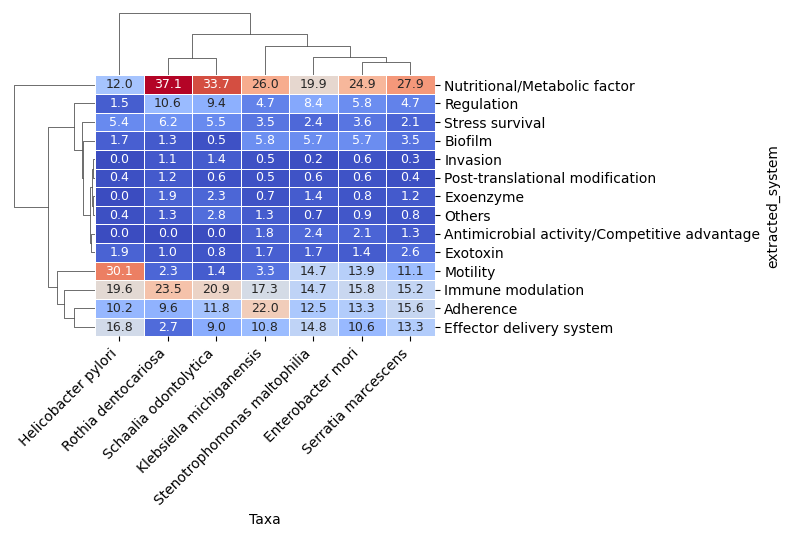

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve default style
#sns.set_theme(style="white")

# Create clustermap
g = sns.clustermap(
    df_wide,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 9},
    cmap="coolwarm",
    linewidths=0.5,
    figsize=(8, 6),
    cbar_pos=None
)

#g.fig.suptitle('%VF genes by category by total VF in all metagenomes', fontsize=6)

#Rotate x-axis labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.savefig("Figures/VF_heatmap.svg", format="svg", bbox_inches="tight")
plt.savefig("Figures/VF_heatmap.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



In [31]:
search_list = ['Serratia marcescens', 'Klebsiella michiganensis' ,'Enterobacter mori','Stenotrophomonas maltophilia','Schaalia odontolytica','Rothia dentocariosa','Helicobacter pylori',]


# 1. Initialize an empty list to store dataframes from each iteration
all_summaries = []

for item in search_list:
    # Filter original dataframe by species
    dfm2_filter = dfm2[dfm2['species'].str.contains(item, na=False)].copy()
    
    # Safely convert to numeric and filter
    dfm2_filter["pident_x"] = pd.to_numeric(dfm2_filter["pident_x"], errors='coerce')
    dfm2_filter = dfm2_filter[dfm2_filter["pident_x"] >= 35]

    # Drop duplicates so we only count a pgfam ONCE per file/sample
    dfm2_filter = dfm2_filter[['file', 'pgfam']].drop_duplicates()
    
    # If no data is found for this item, skip to avoid errors
    if dfm2_filter.empty:
        continue

    # 1. Calculate the total number of unique samples (files) for this taxon
    total_samples = dfm2_filter['file'].nunique()
    
    # 2. Count how many samples each pgfam appears in
    counts = dfm2_filter['pgfam'].value_counts()
    
    # 3. Calculate the percentage of samples that contain each pgfam
    percentages = (counts / total_samples) * 100
    
    # Combine them into a single summary DataFrame
    summary_df = pd.DataFrame({
        'Taxa': item,
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    }).reset_index(names='pgfam')
    
    
    # 2. Append this iteration's dataframe to our list
    all_summaries.append(summary_df)

# 3. Concat everything together after the loop finishes
if all_summaries:
    final_df = pd.concat(all_summaries, ignore_index=True)
else:
    final_df = pd.DataFrame() # Return empty df if no matches were found at all

final_df

####MIGHT NEED TO USE PGFAM INSTEAD OR CLEAN UP VF NAMES

,pgfam,Taxa,Count,Percentage (%)
0,PGF_08225224,Serratia marcescens,21,91.30
1,PGF_00063161,Serratia marcescens,17,73.91
2,PGF_00013017,Serratia marcescens,16,69.57
3,PGF_04276033,Serratia marcescens,16,69.57
4,PGF_00030674,Serratia marcescens,16,69.57
...,...,...,...,...
2963,PGF_00086499,Helicobacter pylori,1,11.11
2964,PGF_03752718,Helicobacter pylori,1,11.11
2965,PGF_03192541,Helicobacter pylori,1,11.11
2966,PGF_01877001,Helicobacter pylori,1,11.11


In [32]:
search_list = ['Serratia marcescens', 'Klebsiella michiganensis' ,'Enterobacter mori','Stenotrophomonas maltophilia','Schaalia odontolytica','Rothia dentocariosa','Helicobacter pylori',]

# 1. Initialize an empty list to store dataframes from each iteration
all_summaries = []

for item in search_list:
    # Filter original dataframe by species
    dfm2_filter = dfm2[dfm2['species'].str.contains(item, na=False)].copy()
    
    # Safely convert to numeric and filter
    dfm2_filter["pident_x"] = pd.to_numeric(dfm2_filter["pident_x"], errors='coerce')
    dfm2_filter = dfm2_filter[dfm2_filter["pident_x"] >= 35]

    # Drop duplicates so we only count a pgfam ONCE per file/sample
    dfm2_filter = dfm2_filter[['pgfam', 'salltitles_x']].drop_duplicates()
    
    # If no data is found for this item, skip to avoid errors
    if dfm2_filter.empty:
        continue

    # Combine them into a single summary DataFrame
    summary_df = dfm2_filter
    
    
    # 2. Append this iteration's dataframe to our list
    all_summaries.append(summary_df)

# 3. Concat everything together after the loop finishes
if all_summaries:
    final_df_key = pd.concat(all_summaries, ignore_index=True)
else:
    final_df_key = pd.DataFrame() # Return empty df if no matches were found at all

final_df_key = final_df_key.drop_duplicates()

regex_pattern = r'\[.*?\s-\s(.*?)\s\('

final_df_key['extracted_system'] = final_df_key['salltitles_x'].str.extract(regex_pattern)

## if pgfam has more than one, concats all in alphabetical order
# final_df_key = final_df_key.groupby('pgfam')['extracted_system'].agg(
#     lambda x: ', '.join(sorted(x.dropna().unique()))
# ).reset_index()

## if pgfam has more than one, takes one that occurs most often
final_df_key = final_df_key.groupby('pgfam')['extracted_system'].agg(
    lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else None
).reset_index()

final_df_key = final_df_key[['pgfam', 'extracted_system']].drop_duplicates()

final_df_key

,pgfam,extracted_system
0,PGF_00000090,Adherence
1,PGF_00000092,Exoenzyme
2,PGF_00001231,Adherence
3,PGF_00001494,Nutritional/Metabolic factor
4,PGF_00001592,Nutritional/Metabolic factor
...,...,...
1528,PGF_12886365,Effector delivery system
1529,PGF_12894146,Regulation
1530,PGF_12894664,Effector delivery system
1531,PGF_12907645,Regulation


In [33]:
final_df = pd.merge(final_df, final_df_key, on = 'pgfam', how = 'left')

In [34]:
df_wide = final_df.pivot(index='pgfam', columns='Taxa', values='Percentage (%)').fillna(0)
df_wide = df_wide.reset_index()
df_wide.columns.name = None

df_wide = pd.merge(df_wide, final_df_key, on = 'pgfam', how = 'left')

df_wide = df_wide.sort_values(by=['extracted_system'])

df_wide

df_long = df_wide.melt(
    id_vars=['pgfam', 'extracted_system'],
    var_name='Organism',
    value_name='Percentage',
)

df_long.to_csv('pgram_vf.csv')

In [ ]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_tile,
    scale_fill_cmap,
    facet_grid,
    theme_minimal,
    theme,
    element_text,
    labs,
)

/home/dcm/env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/dcm/env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


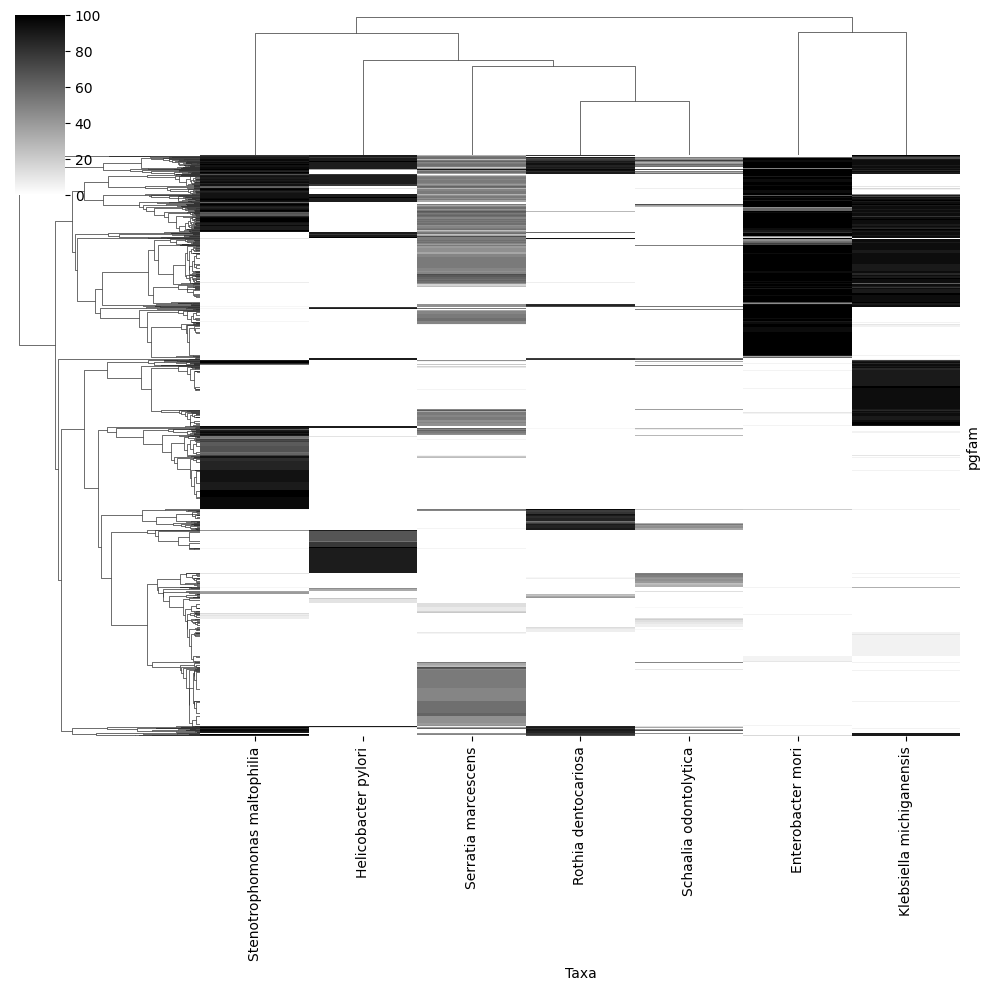

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

df_wide = final_df.pivot(index='pgfam', columns='Taxa', values='Percentage (%)').fillna(0)
df_wide = df_wide[df_wide.sum(axis=1) >= 5]
# 3. Create the heatmap
g = sns.clustermap(df_wide, annot=False, cmap='binary', yticklabels=False)
plt.show()

In [36]:
df_wide

Taxa,Enterobacter mori,Helicobacter pylori,Klebsiella michiganensis,Rothia dentocariosa,Schaalia odontolytica,Serratia marcescens,Stenotrophomonas maltophilia
pgfam,,,,,,,
PGF_00000090,0.0,0.0,0.00,0.00,40.62,0.00,0.00
PGF_00000092,0.0,0.0,0.00,0.00,50.00,0.00,0.00
PGF_00001231,0.0,0.0,0.00,0.00,0.00,0.00,89.29
PGF_00001494,0.0,0.0,10.53,0.00,0.00,0.00,92.86
PGF_00001592,0.0,0.0,89.47,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...
PGF_12882652,0.0,0.0,0.00,0.00,0.00,0.00,57.14
PGF_12886365,5.0,0.0,94.74,0.00,0.00,0.00,0.00
PGF_12894146,0.0,0.0,0.00,0.00,0.00,0.00,89.29


In [ ]:
final_df.columns

In [ ]:
dfm2[dfm2['ARO Name'].str.contains('qnr', case=False, na=False)].to_csv('qnrs.csv')

In [ ]:
#checkM summary stats on select taxa
df_checkm = pd.read_csv('checkm2_contig_bins/checkm2_concat.txt', sep = '\t')
df_checkm

search_list = ['Serratia_marcescens', 'Klebsiella_michiganensis' ,'Enterobacter_mori','Stenotrophomonas_maltophilia','Schaalia_odontolytica','Rothia_dentocariosa','Helicobacter_pylori',]

pattern = '|'.join(search_list)
filtered_df = df_checkm[df_checkm['Species'].str.contains(pattern, na=False)]
filtered_df

unique_items = filtered_df['Species'].dropna().unique()

# 2. Create an empty list to store the summary DataFrame for each group
summary_list = []

# 3. Run the for-loop to filter and get stats
for item in unique_items:
    # Filter the dataframe for the current unique item
    filtered_df2 = filtered_df[filtered_df['Species'] == item]
    
    # Get summary stats across all columns, transpose for better readability
    stats = filtered_df2.describe(include='all').T
    
    # Reset the index so column names become a proper column
    stats = stats.reset_index().rename(columns={'index': 'column_name'})
    
    # Add a marker column so you know which group these stats belong to
    stats['filter_group'] = item
    
    # Append the result to our list
    summary_list.append(stats)

# 4. Concatenate all the summaries together into one master table
final_summary_table = pd.concat(summary_list, ignore_index=True)

# Rearrange columns so group identifiers are on the left
cols = ['filter_group', 'column_name'] + [c for c in final_summary_table.columns if c not in ['filter_group', 'column_name']]
final_summary_table = final_summary_table[cols]

# View the final combined table
final_summary_table.to_csv('checkm_select_taxa.csv')